# Input Generation — German DSO Network Tariffs 2026

## Purpose

This notebook defines and exports the **residential network tariff parameters** for the seven German distribution system operators (DSOs) included in the thesis. All values are sourced directly from each operator's 2026 published *Preisblatt* (tariff sheet) and are hardcoded here for full transparency — no raw data file is required.

**Output files:**
- `inputs/dso_tariffs_residential_2026.csv` — base tariff, §14a Module 1/2/3 rates, seasonality, and time-window summary per DSO  
- `inputs/dso_mod3_timebands_2026.csv` — machine-readable HT/NT band definitions used by the solver to construct 15-min price vectors

## Data sources

- Bayernwerk Netz GmbH. (n.d.). *Netzentgelte Strom*. Retrieved April 14, 2026, from https://www.bayernwerk-netz.de/de/bayernwerk-netz-gmbh/netzinformation/netzentgelte/netzentgelte-strom.html
- E.DIS Netz GmbH. (n.d.). *Netzentgelte Strom*. Retrieved April 14, 2026, from https://www.e-dis-netz.de/de/energie-anschliessen/netznutzung-strom/netzentgelte.html
- MITNETZ Strom GmbH. (n.d.). *Entgelte für Netznutzung*. Retrieved April 14, 2026, from https://www.mitnetz-strom.de/energie-beziehen/netznutzung/entgelte-f%C3%BCr-netznutzung
- Netze BW GmbH. (n.d.). *Veröffentlichungen: Netzentgelte Strom*. Retrieved April 14, 2026, from https://www.netze-bw.de/unternehmen/veroeffentlichungen#3-1
- SH Netz AG. (n.d.). *Entgelte Strom*. Retrieved April 14, 2026, from https://www.sh-netz.com/de/schleswig-holstein-netz/netzinformation/netzentgelte/entgelte-strom.html
- Stromnetz Berlin GmbH. (n.d.). *Netzentgelte*. Retrieved April 14, 2026, from https://www.stromnetz.berlin/netz-nutzen/entgelte/
- Westnetz GmbH. (n.d.). *Netzentgelte*. Retrieved April 14, 2026, from https://www.westnetz.de/netzentgelte

## Thesis reference

Chapter 3, Section 3.2 — *§14a tariff module logic*; Chapter 4, Section 4.5 — *Tariff parameterisation*

In [1]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# -- thesis figure rc (shared across notebooks) --
plt.rcParams.update({
    "axes.titlesize": 11,
    "axes.titleweight": "normal",
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
})

import matplotlib.patches as mpatches

# ── Path configuration ─────────────────────────────────────────────────────────
def find_repo_root(marker='README.md'):
    p = Path(os.getcwd()).resolve()
    for candidate in [p, *p.parents]:
        if (candidate / marker).exists():
            return candidate
    raise RuntimeError(f'Repo root not found (looked for: {marker})')

REPO_ROOT      = find_repo_root()
INPUTS         = REPO_ROOT / 'inputs'
INPUTS.mkdir(parents=True, exist_ok=True)
OUT_TARIFFS    = INPUTS / 'dso_tariffs_residential_2026.csv'
OUT_TIMEBANDS  = INPUTS / 'dso_mod3_timebands_2026.csv'

# ── DSO ordering ───────────────────────────────────────────────────────────────
DSO_ORDER = [
    'Westnetz', 'Bayernwerk', 'E.DIS', 'Netze BW',
    'Stromnetz Berlin', 'SH Netz', 'MITNETZ STROM',
]

# ── Base residential tariff (SLP low-voltage, net of VAT) ──────────────────────
# Arbeitspreis: volumetric energy charge (ct/kWh).
# Grundpreis:   fixed annual connection charge (€/year).
base = pd.DataFrame({
    'DSO':                    DSO_ORDER,
    'Arbeitspreis_ct_kWh':    [9.53, 4.72, 5.47, 7.57, 7.46, 6.40, 6.31],
    'Grundpreis_EUR_year':    [80.30, 98.55, 76.65, 84.00, 33.36, 94.90, 73.00],
})

# ── §14a Module 1 — annual flat rebate (€/year, negative = cost reduction) ─────
mod1 = pd.DataFrame({
    'DSO':                        DSO_ORDER,
    'Module1_rebate_EUR_year':    [-138.70, -123.18, -108.25, -180.78, -123.18, -115.23, -114.55],
})

# ── §14a Module 2 — reduced flat volumetric rate (ct/kWh, replaces Arbeitspreis) 
mod2 = pd.DataFrame({
    'DSO':              DSO_ORDER,
    'Module2_ct_kWh':  [3.81, 1.89, 2.19, 3.03, 2.98, 2.56, 2.52],
})

# ── §14a Module 3 — time-of-use rates (ct/kWh, net of VAT) ────────────────────
# HT (Hochtarif): peak rate during defined high-demand windows.
# NT (Niedertarif): off-peak rate during low-demand windows.
# ST (Standardtarif): base rate applied outside HT/NT windows, or in inactive quarters.
# Module 3 can only be combined with Module 1 (not Module 2).
mod3 = pd.DataFrame({
    'DSO':           DSO_ORDER,
    'HT_ct_kWh':     [15.65, 9.03, 8.80, 11.06, 13.94, 8.32, 12.62],
    'NT_ct_kWh':     [0.95,  0.47, 0.55,  3.03,  2.61, 0.64,  0.69],
    'ST_ct_kWh':     [9.53,  4.72, 5.47,  7.57,  7.46, 6.40,  6.31],  # equals Arbeitspreis
    'Seasonality':   ['Year-round', 'Q2/Q3 only', 'Q1/Q4 only', 'Year-round',
                      'Year-round', 'Q1/Q4 only', 'Q1/Q4 only'],
    'Active_quarters': ['Q1–Q4', 'Q2+Q3 only', 'Q1+Q4 only', 'Q1–Q4',
                        'Q1–Q4', 'Q1+Q4 only', 'Q1+Q4 only'],
    'Window_type':   ['Fixed year-round', 'Fixed (Q2/Q3)', 'Fixed (Q1/Q4)', 'Fixed year-round',
                      'Fixed year-round', 'Fixed (Q1/Q4)', 'Fixed (Q1/Q4)'],
    'Time_windows_HT_NT_ST': [
        'Year-round, fixed daily: HT 15:00–20:00, NT 00:00–07:00, ST 07:00–15:00 & 20:00–24:00.',
        'Q2/Q3: HT 17:00–22:00, NT 10:00–15:00, ST other. Q1/Q4: ST only (base rate).',
        'Q1/Q4: HT 10:15–12:00, 16:45–20:15; NT 00:00–05:00, 23:30–24:00; ST other. Q2/Q3: ST only.',
        'Year-round: HT 17:00–22:00, NT 10:00–14:00, ST 00:00–10:00, 14:00–17:00, 22:00–00:00.',
        'Year-round: HT 17:15–20:15, NT 22:15–06:30, ST 06:30–17:15, 20:15–22:15.',
        'Q1/Q4: HT 09:00–14:00, 17:00–21:00; NT 00:00–05:00, 22:00–24:00; ST other. Q2/Q3: ST only.',
        'Q1/Q4: HT 08:00–12:00, 17:00–19:00; NT 00:00–03:00, 19:00–24:00; ST other. Q2/Q3: ST only.',
    ],
})
mod3['Spread_ct_kWh'] = (mod3['HT_ct_kWh'] - mod3['NT_ct_kWh']).round(2)

# ── Module 3 time-band definitions (machine-readable for solver) ───────────────
# Each row specifies one contiguous HT or NT interval for a DSO/quarter-group.
# start_hour / end_hour in decimal hours [0, 24]; ST is the implicit complement.
timebands_rows = [
    # Westnetz — fixed year-round
    {'DSO': 'Westnetz',          'quarter_group': 'all',  'band': 'HT', 'start_hour':  15.00, 'end_hour': 20.00},
    {'DSO': 'Westnetz',          'quarter_group': 'all',  'band': 'NT', 'start_hour':   0.00, 'end_hour':  7.00},
    # Bayernwerk — Q2/Q3 only
    {'DSO': 'Bayernwerk',        'quarter_group': 'q2q3', 'band': 'HT', 'start_hour':  17.00, 'end_hour': 22.00},
    {'DSO': 'Bayernwerk',        'quarter_group': 'q2q3', 'band': 'NT', 'start_hour':  10.00, 'end_hour': 15.00},
    # E.DIS — Q1/Q4 only, disjoint bands
    {'DSO': 'E.DIS',             'quarter_group': 'q1q4', 'band': 'HT', 'start_hour':  10.25, 'end_hour': 12.00},
    {'DSO': 'E.DIS',             'quarter_group': 'q1q4', 'band': 'HT', 'start_hour':  16.75, 'end_hour': 20.25},
    {'DSO': 'E.DIS',             'quarter_group': 'q1q4', 'band': 'NT', 'start_hour':   0.00, 'end_hour':  5.00},
    {'DSO': 'E.DIS',             'quarter_group': 'q1q4', 'band': 'NT', 'start_hour':  23.50, 'end_hour': 24.00},
    # Netze BW — fixed year-round
    {'DSO': 'Netze BW',          'quarter_group': 'all',  'band': 'HT', 'start_hour':  17.00, 'end_hour': 22.00},
    {'DSO': 'Netze BW',          'quarter_group': 'all',  'band': 'NT', 'start_hour':  10.00, 'end_hour': 14.00},
    # Stromnetz Berlin — fixed year-round (NT crosses midnight)
    {'DSO': 'Stromnetz Berlin',  'quarter_group': 'all',  'band': 'HT', 'start_hour':  17.25, 'end_hour': 20.25},
    {'DSO': 'Stromnetz Berlin',  'quarter_group': 'all',  'band': 'NT', 'start_hour':  22.25, 'end_hour':  6.50},
    # SH Netz — HT in Q1/Q4 only; NT bands apply year-round
    {'DSO': 'SH Netz',           'quarter_group': 'all',  'band': 'NT', 'start_hour':   0.00, 'end_hour':  5.00},
    {'DSO': 'SH Netz',           'quarter_group': 'all',  'band': 'NT', 'start_hour':  22.00, 'end_hour': 24.00},
    {'DSO': 'SH Netz',           'quarter_group': 'q1q4', 'band': 'HT', 'start_hour':   9.00, 'end_hour': 14.00},
    {'DSO': 'SH Netz',           'quarter_group': 'q1q4', 'band': 'HT', 'start_hour':  17.00, 'end_hour': 21.00},
    # MITNETZ STROM — Q1/Q4 only, disjoint bands
    {'DSO': 'MITNETZ STROM',     'quarter_group': 'q1q4', 'band': 'HT', 'start_hour':   8.00, 'end_hour': 12.00},
    {'DSO': 'MITNETZ STROM',     'quarter_group': 'q1q4', 'band': 'HT', 'start_hour':  17.00, 'end_hour': 19.00},
    {'DSO': 'MITNETZ STROM',     'quarter_group': 'q1q4', 'band': 'NT', 'start_hour':   0.00, 'end_hour':  3.00},
    {'DSO': 'MITNETZ STROM',     'quarter_group': 'q1q4', 'band': 'NT', 'start_hour':  19.00, 'end_hour': 24.00},
]
df_timebands = pd.DataFrame(timebands_rows)

print(f'Outputs: {OUT_TARIFFS.name}, {OUT_TIMEBANDS.name}')

Outputs: dso_tariffs_residential_2026.csv, dso_mod3_timebands_2026.csv


## Step 1 — Table 2: Residential base tariffs

In [2]:
# Annual cost at 4,500 kWh = Arbeitspreis [ct/kWh] × 45 + Grundpreis [€/year].
# 4,500 kWh is the representative annual consumption used throughout the thesis (Chapter 3).
table2 = base.copy()
table2['Annual_4500_kWh_EUR'] = (table2['Arbeitspreis_ct_kWh'] * 45 + table2['Grundpreis_EUR_year']).round(2)
westnetz_cost = table2.loc[table2['DSO'] == 'Westnetz', 'Annual_4500_kWh_EUR'].iloc[0]
table2['vs_Westnetz'] = ((table2['Annual_4500_kWh_EUR'] - westnetz_cost) / westnetz_cost * 100).round(0)
table2['vs_Westnetz'] = table2['vs_Westnetz'].apply(
    lambda x: '— (baseline)' if x == 0.0 else f'{x:+.0f}%'
)
display(table2.rename(columns={
    'Arbeitspreis_ct_kWh': 'Arbeitspreis (ct/kWh)',
    'Grundpreis_EUR_year': 'Grundpreis (€/year)',
    'Annual_4500_kWh_EUR': 'Annual cost at 4,500 kWh',
    'vs_Westnetz': 'vs. Westnetz',
}))

,DSO,Arbeitspreis (ct/kWh),Grundpreis (€/year),"Annual cost at 4,500 kWh",vs. Westnetz
0,Westnetz,9.53,80.30,509.15,— (baseline)
1,Bayernwerk,4.72,98.55,310.95,-39%
2,E.DIS,5.47,76.65,322.80,-37%
3,Netze BW,7.57,84.00,424.65,-17%
4,Stromnetz Berlin,7.46,33.36,369.06,-28%
5,SH Netz,6.40,94.90,382.90,-25%
6,MITNETZ STROM,6.31,73.00,356.95,-30%


## Step 2 — Table 3: §14a Module 3 time windows and Module 2 prices

In [3]:
# Compact HT and NT window strings for Table 3 display.
ht_windows = {
    'Westnetz':         '15:00–20:00',
    'Bayernwerk':       '17:00–22:00',
    'E.DIS':            '10:15–12:00; 16:45–20:15',
    'Netze BW':         '17:00–22:00',
    'Stromnetz Berlin': '17:15–20:15',
    'SH Netz':          '09:00–14:00; 17:00–21:00',
    'MITNETZ STROM':    '08:00–12:00; 17:00–19:00',
}
nt_windows = {
    'Westnetz':         '00:00–07:00',
    'Bayernwerk':       '10:00–15:00',
    'E.DIS':            '00:00–05:00; 23:30–24:00',
    'Netze BW':         '10:00–14:00',
    'Stromnetz Berlin': '22:15–06:30',
    'SH Netz':          '00:00–05:00; 22:00–24:00',
    'MITNETZ STROM':    '00:00–03:00; 19:00–24:00',
}

table3 = pd.DataFrame({
    'DSO':           DSO_ORDER,
    'Mod 3 quarters': mod3['Active_quarters'].values,
    'HT window':     [ht_windows[d] for d in DSO_ORDER],
    'HT':            mod3['HT_ct_kWh'].values,
    'NT window':     [nt_windows[d] for d in DSO_ORDER],
    'NT':            mod3['NT_ct_kWh'].values,
    'Mod. 2':        mod2['Module2_ct_kWh'].values,
})
display(table3)

,DSO,Mod 3 quarters,HT window,HT,NT window,NT,Mod. 2
0,Westnetz,Q1–Q4,15:00–20:00,15.65,00:00–07:00,0.95,3.81
1,Bayernwerk,Q2+Q3 only,17:00–22:00,9.03,10:00–15:00,0.47,1.89
2,E.DIS,Q1+Q4 only,10:15–12:00; 16:45–20:15,8.80,00:00–05:00; 23:30–24:00,0.55,2.19
3,Netze BW,Q1–Q4,17:00–22:00,11.06,10:00–14:00,3.03,3.03
4,Stromnetz Berlin,Q1–Q4,17:15–20:15,13.94,22:15–06:30,2.61,2.98
5,SH Netz,Q1+Q4 only,09:00–14:00; 17:00–21:00,8.32,00:00–05:00; 22:00–24:00,0.64,2.56
6,MITNETZ STROM,Q1+Q4 only,08:00–12:00; 17:00–19:00,12.62,00:00–03:00; 19:00–24:00,0.69,2.52


## Step 3 — Figure 2: Base tariff levels and §14a Module 3 flexibility spread

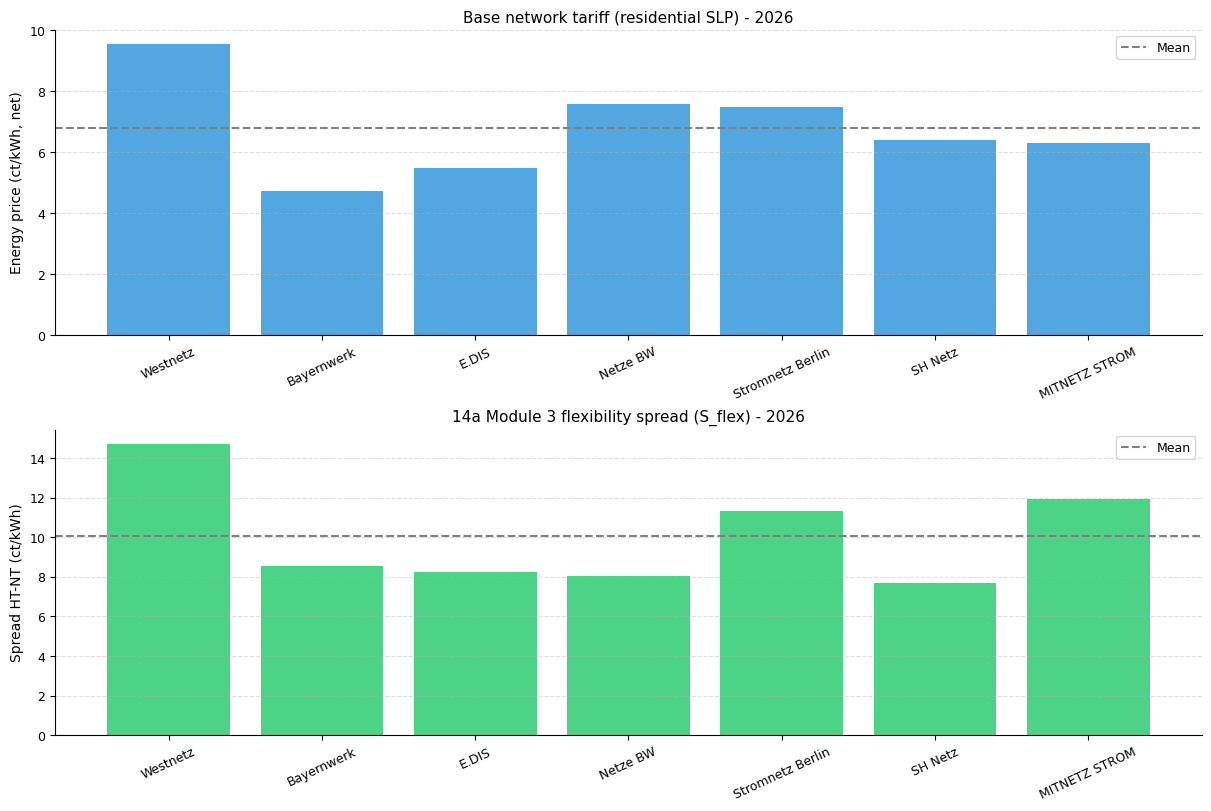

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8), constrained_layout=True)

ax1 = axes[0]
colors_base = ['#3498db' for d in DSO_ORDER]
ax1.bar(DSO_ORDER, base['Arbeitspreis_ct_kWh'], color=colors_base, alpha=0.85)
ax1.axhline(base['Arbeitspreis_ct_kWh'].mean(), color='gray', linestyle='--', label='Mean')
ax1.set_ylabel('Energy price (ct/kWh, net)')
ax1.set_title('Base network tariff (residential SLP) - 2026')
ax1.tick_params(axis='x', rotation=25)
ax1.legend()
ax1.grid(axis='y', linestyle='--', alpha=0.4)
ax1.spines[['top', 'right']].set_visible(False)

ax2 = axes[1]
ax2.bar(DSO_ORDER, mod3['Spread_ct_kWh'], color='#2ecc71', alpha=0.85)
ax2.axhline(mod3['Spread_ct_kWh'].mean(), color='gray', linestyle='--', label='Mean')
ax2.set_ylabel('Spread HT-NT (ct/kWh)')
ax2.set_title('14a Module 3 flexibility spread (S_flex) - 2026')
ax2.tick_params(axis='x', rotation=25)
ax2.legend()
ax2.grid(axis='y', linestyle='--', alpha=0.4)
ax2.spines[['top', 'right']].set_visible(False)

plt.show()


## Step 4 — Figure 3: §14a Module 3 quarterly activation heatmap

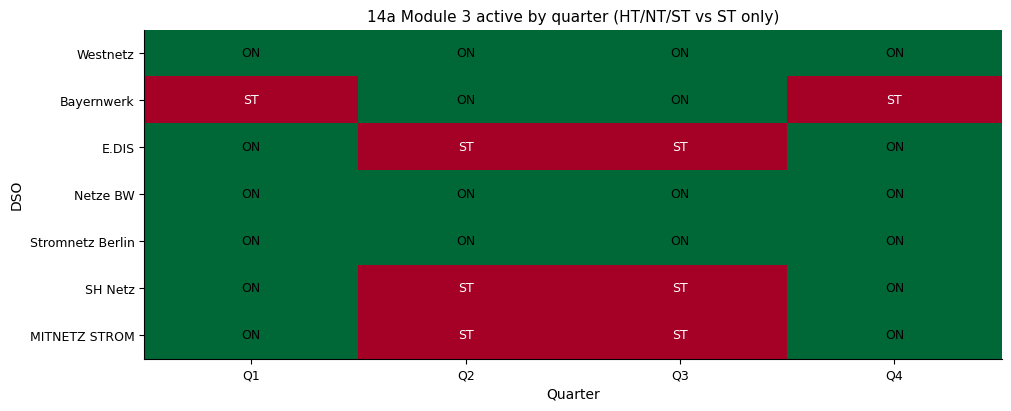

In [5]:
# 1 = HT/NT/ST scheme active; 0 = ST-only (base rate) in that quarter.
quarters = ['Q1', 'Q2', 'Q3', 'Q4']
active_matrix = pd.DataFrame({
    'Westnetz':         [1, 1, 1, 1],
    'Bayernwerk':       [0, 1, 1, 0],
    'E.DIS':            [1, 0, 0, 1],
    'Netze BW':         [1, 1, 1, 1],
    'Stromnetz Berlin': [1, 1, 1, 1],
    'SH Netz':          [1, 0, 0, 1],
    'MITNETZ STROM':    [1, 0, 0, 1],
}, index=quarters)

fig, ax = plt.subplots(figsize=(10, 4), constrained_layout=True)
ax.imshow(active_matrix.T, cmap='RdYlGn', vmin=0, vmax=1, aspect='auto')
ax.set_xticks(range(4))
ax.set_xticklabels(quarters)
ax.set_yticks(range(len(DSO_ORDER)))
ax.set_yticklabels(DSO_ORDER)
ax.set_xlabel('Quarter')
ax.set_ylabel('DSO')
ax.set_title('14a Module 3 active by quarter (HT/NT/ST vs ST only)')
for i, dso in enumerate(DSO_ORDER):
    for j, q in enumerate(quarters):
        label = 'ON' if active_matrix.loc[q, dso] == 1 else 'ST'
        ax.text(j, i, label, ha='center', va='center', fontsize=9,
                color='white' if active_matrix.loc[q, dso] == 0 else 'black')
ax.spines[['top', 'right']].set_visible(False)

plt.show()


## Step 5 — Export to CSV

In [6]:
# ── Export 1: full residential tariff table (one row per DSO) ─────────────────
df_tariffs = (
    base
    .merge(mod1, on='DSO')
    .merge(mod2, on='DSO')
    .merge(mod3[['DSO', 'HT_ct_kWh', 'NT_ct_kWh', 'ST_ct_kWh', 'Spread_ct_kWh',
                  'Seasonality', 'Active_quarters', 'Window_type', 'Time_windows_HT_NT_ST']], on='DSO')
)
df_tariffs.to_csv(OUT_TARIFFS, index=False)
print(f'Exported: {OUT_TARIFFS.name}  ({len(df_tariffs)} rows × {len(df_tariffs.columns)} cols)')

# ── Export 2: machine-readable HT/NT time-band definitions ───────────────────
df_timebands.to_csv(OUT_TIMEBANDS, index=False)
print(f'Exported: {OUT_TIMEBANDS.name}  ({len(df_timebands)} rows)')

Exported: dso_tariffs_residential_2026.csv  (7 rows × 13 cols)
Exported: dso_mod3_timebands_2026.csv  (20 rows)
